# Imports

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Conversion function

In [ ]:
def convert_rgb_image_to_ycbcr(rgb_image):
    """
    Convert an RGB image to YCbCr color space.

    OpenCV uses the channel order:
    Y, Cr, Cb
    for cv2.COLOR_RGB2YCrCb.
    """
    ycrcb_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2YCrCb)

    # Rearrange OpenCV's YCrCb output into YCbCr order
    ycbcr_image = ycrcb_image[:, :, [0, 2, 1]]

    return ycbcr_image

# Read and convert Image

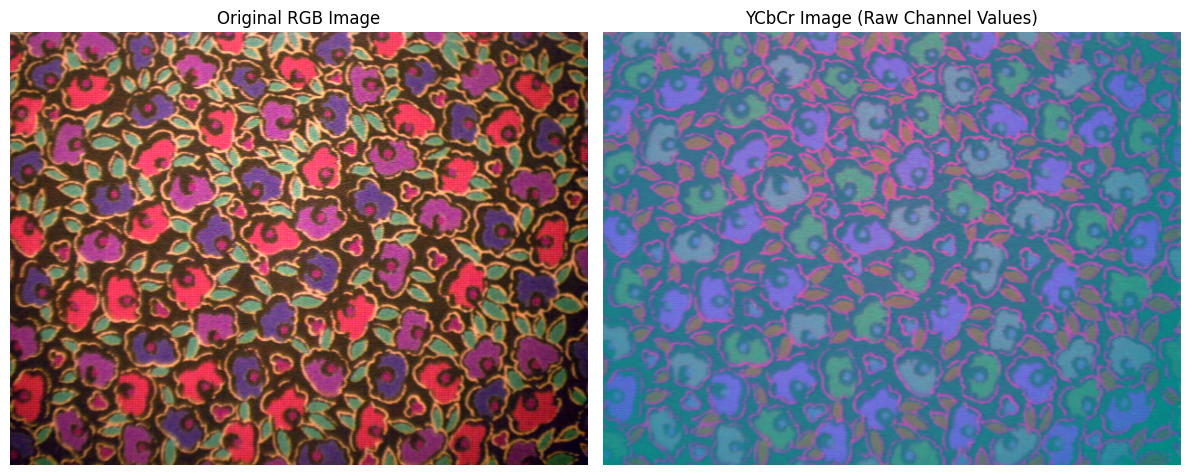

In [ ]:
bgr_image = cv2.imread("fabric.png") # opencv reads the image in BGR format

# Convert BGR to RGB because the given image is considered RGB
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)

# Convert RGB image to YCbCr
ycbcr_image = convert_rgb_image_to_ycbcr(rgb_image)


# Display the images
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title("Original RGB Image")
plt.axis("off")

plt.subplot(1, 2, 2)
# Direct display is only for visualizing the stored channel values.
# Matplotlib interprets these values as RGB, so colors will not be
# physically correct YCbCr colors.
plt.imshow(ycbcr_image)
plt.title("YCbCr Image (Raw Channel Values)")
plt.axis("off")

plt.tight_layout()
plt.show()

# Random pixel from the Image comparison

In [ ]:
# Get image height and width
height, width = rgb_image.shape[:2]

# Randomly select one pixel location
row = np.random.randint(0, height)
col = np.random.randint(0, width)

# Get RGB value at that pixel
rgb_value = rgb_image[row, col]

# Get corresponding YCbCr value at the same pixel
ycbcr_value = ycbcr_image[row, col]

# Convert NumPy values to normal Python integers
rgb_value = [int(x) for x in rgb_value]
ycbcr_value = [int(x) for x in ycbcr_value]

# Print results
print("Random pixel location:", (row, col))
print("RGB value:", rgb_value)
print("YCbCr value:", ycbcr_value)

Random pixel location: (39, 40)
RGB value: [95, 64, 123]
YCbCr value: [80, 152, 139]


# Visualization of Individual Y, Cb, and Cr Channels

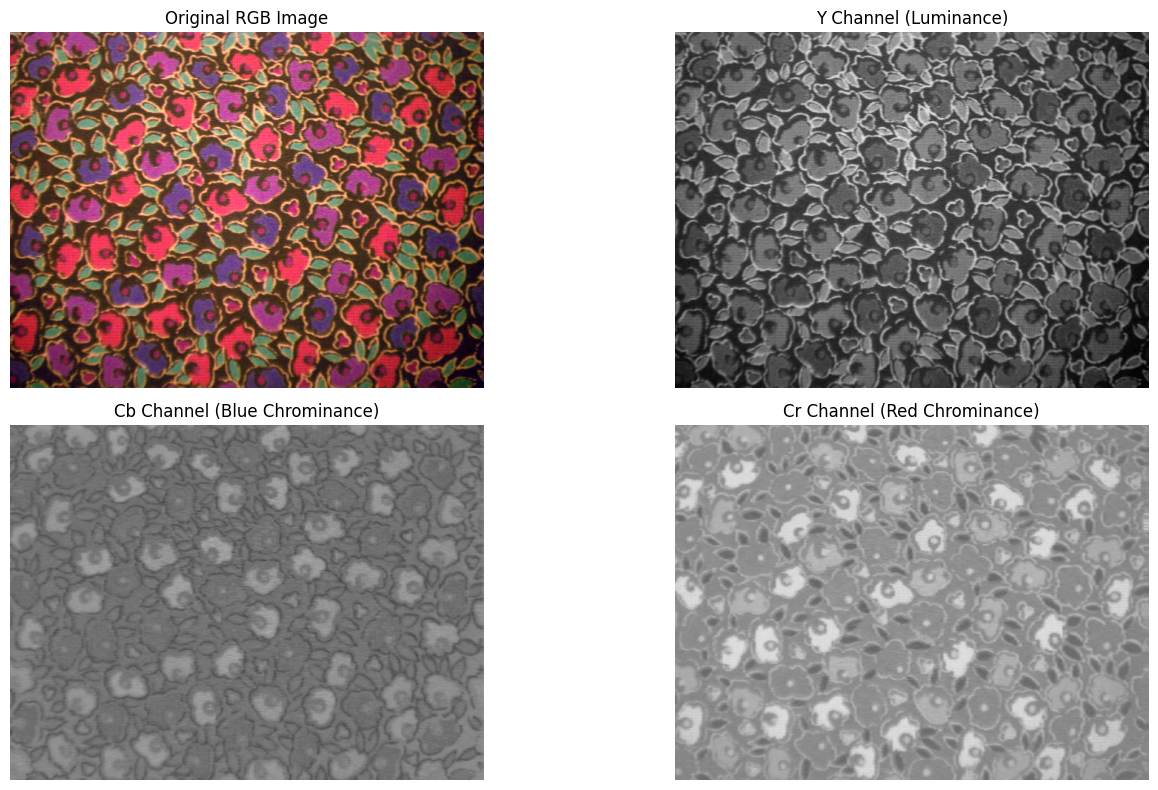

In [ ]:
# Extract individual channels
Y = ycbcr_image[:, :, 0]
Cb = ycbcr_image[:, :, 1]
Cr = ycbcr_image[:, :, 2]


# Display original image and separate channels
plt.figure(figsize=(15, 8))

# Original RGB image
plt.subplot(2, 2, 1)
plt.imshow(rgb_image)
plt.title("Original RGB Image")
plt.axis("off")

# Y channel
plt.subplot(2, 2, 2)
plt.imshow(Y, cmap="gray", vmin=0, vmax=255)
plt.title("Y Channel (Luminance)")
plt.axis("off")

# Cb channel
plt.subplot(2, 2, 3)
plt.imshow(Cb, cmap="gray", vmin=0, vmax=255)
plt.title("Cb Channel (Blue Chrominance)")
plt.axis("off")

# Cr channel
plt.subplot(2, 2, 4)
plt.imshow(Cr, cmap="gray", vmin=0, vmax=255)
plt.title("Cr Channel (Red Chrominance)")
plt.axis("off")

plt.tight_layout()
plt.show()

# Additional experiment: RGB to YCbCr values for some standard colors

In [ ]:
colors = {
    "Red":    [255, 0, 0],
    "Green":  [0, 255, 0],
    "Blue":   [0, 0, 255],
    "Black":  [0, 0, 0],
    "White":  [255, 255, 255],
    "Yellow": [255, 255, 0],
    "Pink":   [255, 105, 180]
}

# Convert RGB values to YCbCr values
# OpenCV gives Y, Cr, Cb, so rearrange to Y, Cb, Cr

def rgb_to_ycbcr(rgb):
    rgb_pixel = np.array([[rgb]], dtype=np.uint8)

    ycrcb = cv2.cvtColor(rgb_pixel, cv2.COLOR_RGB2YCrCb)

    Y = int(ycrcb[0, 0, 0])
    Cr = int(ycrcb[0, 0, 1])
    Cb = int(ycrcb[0, 0, 2])

    return [Y, Cb, Cr]

# Print RGB and YCbCr values

print("Color\t\tRGB\t\t\tYCbCr")
print("-" * 55)

for name, rgb in colors.items():
    ycbcr = rgb_to_ycbcr(rgb)

    print(f"{name:8s}\t{rgb}\t\t{ycbcr}")

Color		RGB			YCbCr
-------------------------------------------------------
Red     	[255, 0, 0]		[76, 85, 255]
Green   	[0, 255, 0]		[150, 43, 21]
Blue    	[0, 0, 255]		[29, 255, 107]
Black   	[0, 0, 0]		[0, 128, 128]
White   	[255, 255, 255]		[255, 128, 128]
Yellow  	[255, 255, 0]		[226, 1, 149]
Pink    	[255, 105, 180]		[158, 140, 197]
